## Script for statistics of binary relevance and classifier chains of benchmarks


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import prediction_handler as result_handler
import os
from sklearn.metrics import jaccard_score, roc_auc_score

In [1]:
#setting filepaths of the results

pi_results_filepath = "../prediction_results/PI_results/PI_"

nnrti_results_filepath = "../prediction_results/NNRTI_results/NNRTI_"

nrti_results_filepath = "../prediction_results/NRTI_results/NRTI_"

ini_results_filepath = "../prediction_results/INI_results/INI_"



#creating lists with filepaths for later visualisation
filepath_list = [pi_results_filepath, nnrti_results_filepath, nrti_results_filepath, ini_results_filepath]




#setting filepaths the datasets

pi_results_filepath_ml = "../prediction_results/PI_results/benchmarkings/PI_"

nnrti_results_filepath_ml = "../prediction_results/NNRTI_results/benchmarkings/NNRTI_"

nrti_results_filepath_ml = "../prediction_results/NRTI_results/benchmarkings/NRTI_"

ini_results_filepath_ml = "../prediction_results/INI_results/benchmarkings/INI_"



#creating lists with filepaths for later visualisation
filepath_list_ml = [pi_results_filepath_ml, nnrti_results_filepath_ml, nrti_results_filepath_ml, ini_results_filepath_ml]



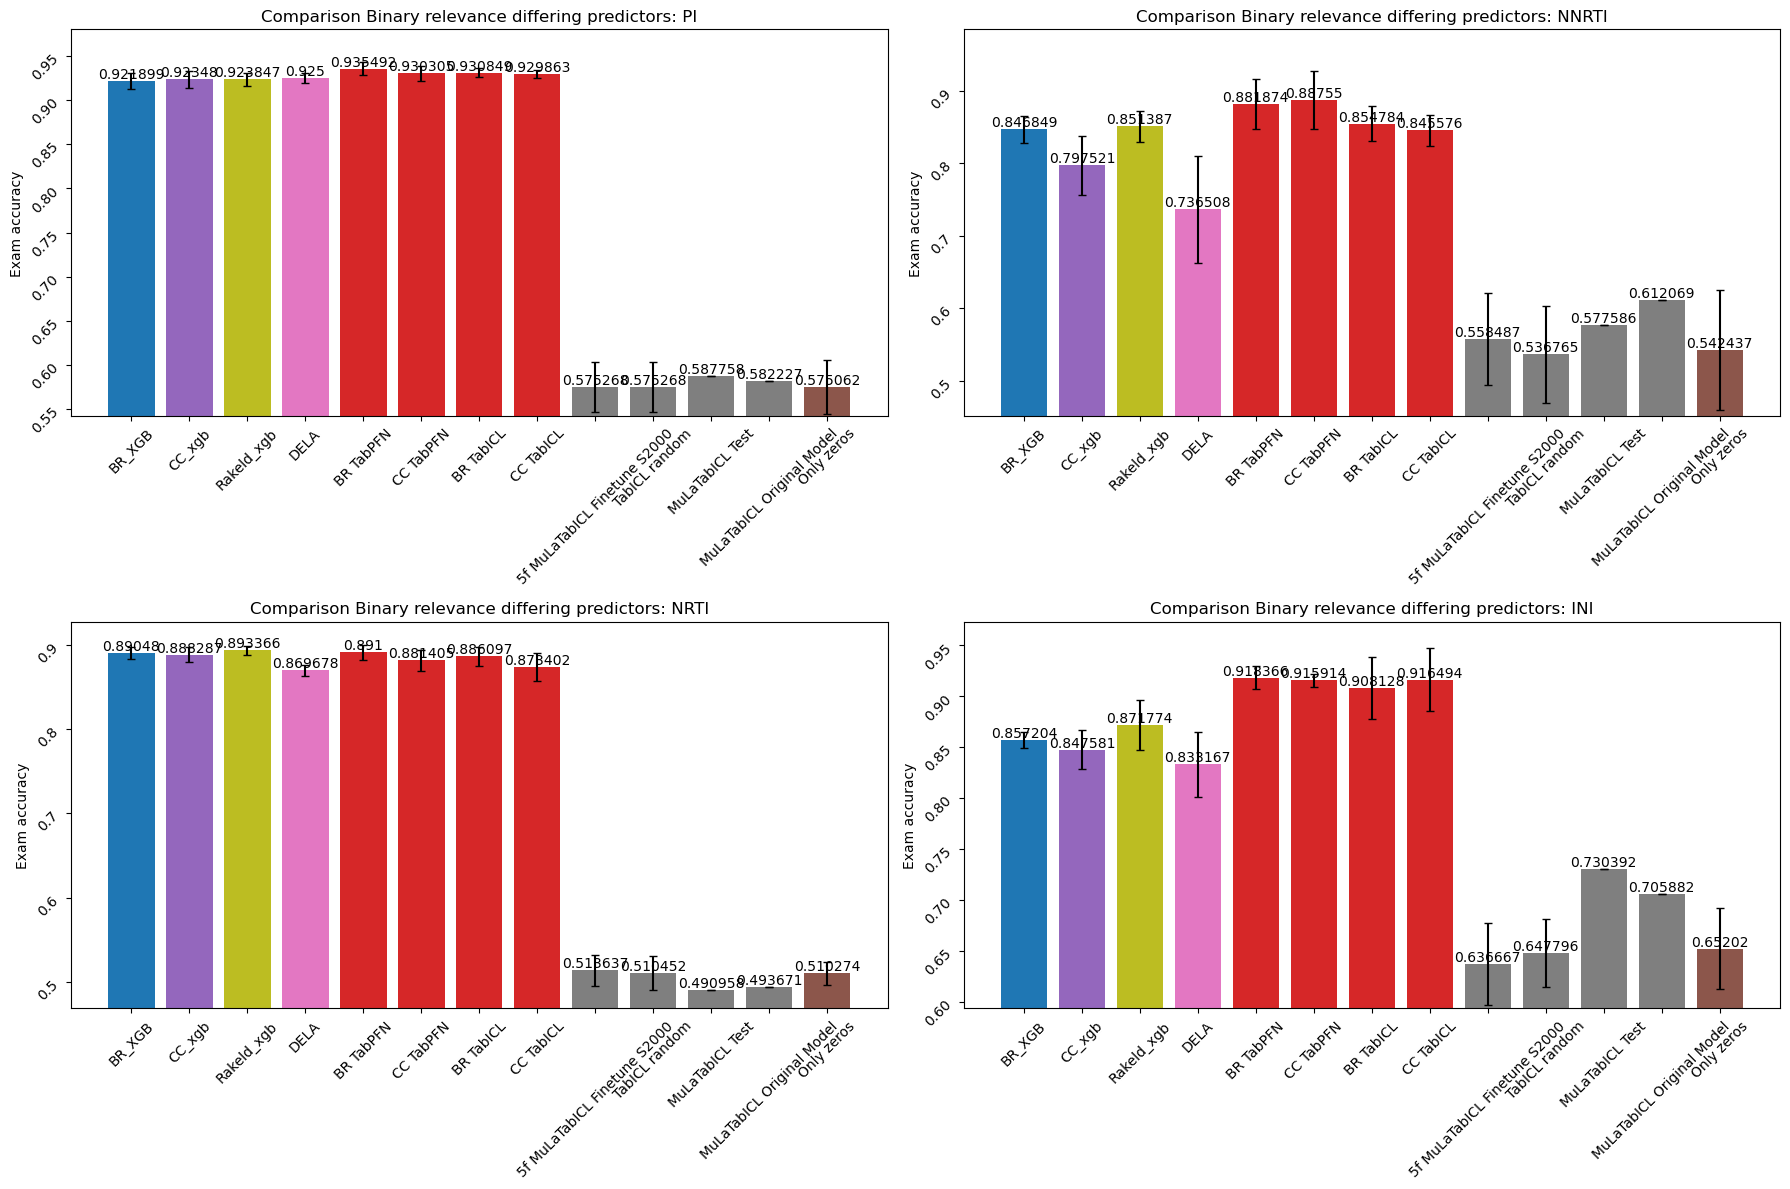

In [3]:


ml_models = ["BR_XGB", "CC_xgb"]

ending = "_5_fold.csv"

sub_accs_fold_mean = {}
sub_accs_fold_std = {}

for path in filepath_list_ml:

    acc_list_mean = []
    acc_list_std = []
    #rakel_results = []

    for model in ml_models:

        results = pd.read_csv(path + model + ending)

        #results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: result_handler.exam_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

        #else:
        #    rakel_results.append(sub_acc)

    #sub_accs.update({path.split("/")[-1].strip("_"):[br_results, cc_results, rakel_results]})
    sub_accs_fold_mean.update({path.split("/")[-1].strip("_"):acc_list_mean})
    sub_accs_fold_std.update({path.split("/")[-1].strip("_"):acc_list_std})

files1 = ["Rakeld_xgb", "DELA"]

for path in filepath_list_ml:
    acc_list_mean = []
    acc_list_std = []

    for file in files1:
        results = pd.read_csv(path + file + ending)

        results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: result_handler.exam_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

    sub_accs_fold_mean[path.split("/")[-1].strip("_")].extend(acc_list_mean)
    sub_accs_fold_std[path.split("/")[-1].strip("_")].extend(acc_list_std)


files = ["Binary_Relevance_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_new_save.csv", "Binary_Relevance_5_fold_tabicl_prediction_new_save.csv", "Classifier_Chain_5_fold_tabicl_prediction_woNaN_new_save.csv", "MuLaTabICL_finetune_step2000_5_fold.csv", "MuLaTabICL_random_step1_5_fold.csv"]


for path in filepath_list:
    acc_list_mean = []
    acc_list_std = []

    for file in files:
        results = pd.read_csv(path + file)

        results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: result_handler.exam_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

    sub_accs_fold_mean[path.split("/")[-1].strip("_")].extend(acc_list_mean)
    sub_accs_fold_std[path.split("/")[-1].strip("_")].extend(acc_list_std)


MuLaTabICL_list = ["MuLaTabICL.csv", "MuLaTabICL_orig_model.csv"]

for path in filepath_list:

    for mula in MuLaTabICL_list:
        results = pd.read_csv(path + mula)

        results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        true_labels = results.filter(regex="True_*")
        pred_labels = results.filter(regex="Pred_*")

        sub_acc = result_handler.exam_acc(pred_labels, true_labels)

        sub_accs_fold_mean[path.split("/")[-1].strip("_")].append(sub_acc)
        sub_accs_fold_std[path.split("/")[-1].strip("_")].append(0)


for path in filepath_list:


    results = pd.read_csv(path + "Binary_Relevance_5_fold_homebrew_prediction_new_save.csv")

    results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

    subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: result_handler.exam_acc(pd.DataFrame(np.zeros_like(x.filter(regex="Pred_*"))), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)

    sub_accs_fold_mean[path.split("/")[-1].strip("_")].append(subs_accs_groups.mean())
    sub_accs_fold_std[path.split("/")[-1].strip("_")].append(subs_accs_groups.std())



df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)


models_w_TabPFN = ["BR TabPFN", "CC TabPFN", "BR TabICL", "CC TabICL", "5f MuLaTabICL Finetune S2000", "TabICL random", "MuLaTabICL Test", "MuLaTabICL Original Model", "Only zeros"]

color = ["tab:blue"] + ["tab:purple"] + ["tab:olive"] + ["tab:pink"] + ["tab:red"] * 4 + ["tab:gray"] * 4 + ["tab:brown"]

fig, axs = plt.subplots(2, 2, figsize=(18, 12))
#fig.tight_layout()

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):


    labels = ml_models + files1 + models_w_TabPFN
    p = axs[i].bar(labels, df_sub_accs_groups_mean[drug], color=color)
    axs[i].errorbar(labels, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")


    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].tick_params(rotation=45)
    axs[i].set_ylabel('Exam accuracy')
    axs[i].set_ylim(max(0, (df_sub_accs_groups_mean[drug].min() - df_sub_accs_groups_std[drug].max()) * 0.995), min(1.0 + df_sub_accs_groups_std[drug].max(), (df_sub_accs_groups_mean[drug].max() + df_sub_accs_groups_std[drug].max())  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)

fig.tight_layout()
#plt.show()

#plt.savefig("../figures/All_benchmark_comparison_examAcc_wTabICL_wo_NaN.png")


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (11,) and arg 1 with shape (12,).

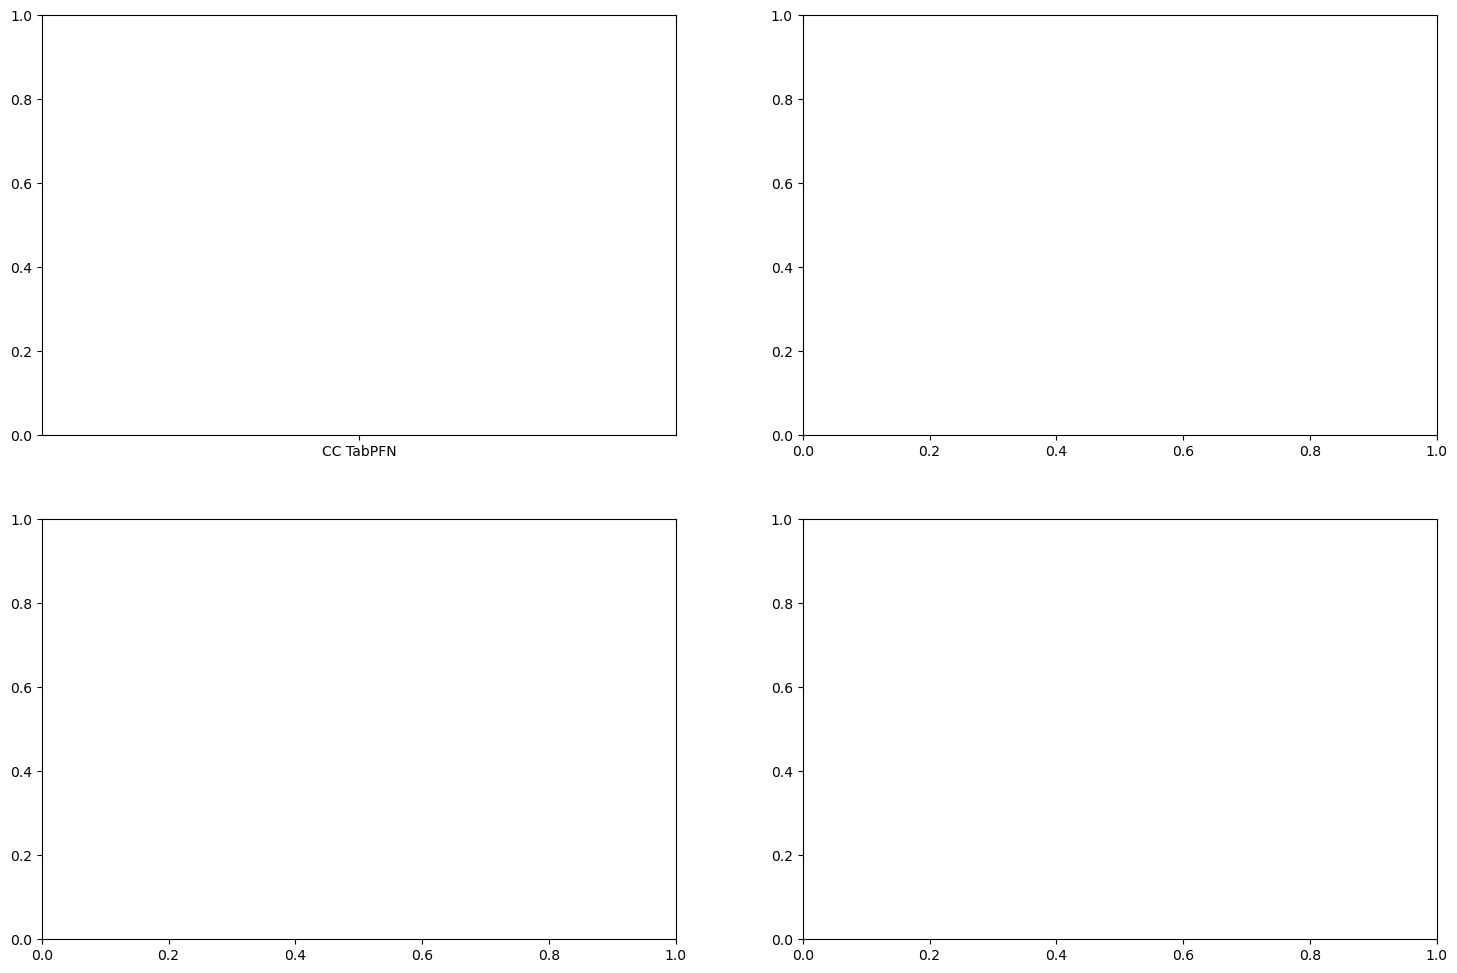

In [12]:


ending = "_5_fold.csv"

sub_accs_fold_mean = {}
sub_accs_fold_std = {}


files = ["Classifier_Chain_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_5_fold_tabicl_prediction_woNaN_new_save.csv", "MuLaTabICL_full_model_step-1000_5_foldnew_loss.csv", "MuLaTabICL_finetune_step2000_5_fold.csv","MuLaTabICL_finetune_step-3150.ckpt_5_fold.csv","MuLaTabICL_bal_prior_step-1350.ckpt_5_fold.csv", "MuLaTabICL_bal_prior_step-1000.ckpt_5_fold.csv", "MuLaTabICL_full_model_step-1000.ckpt_5_fold.csv"]


for path in filepath_list:
    acc_list_mean = []
    acc_list_std = []

    for file in files:
        results = pd.read_csv(path + file)

        results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: result_handler.exam_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)


        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

    sub_accs_fold_mean.update({path.split("/")[-1].strip("_"):acc_list_mean})
    sub_accs_fold_std.update({path.split("/")[-1].strip("_"):acc_list_std})



MuLaTabICL_list = ["MuLaTabICL.csv", "MuLaTabICL_orig_model.csv"]

for path in filepath_list:

    for mula in MuLaTabICL_list:
        results = pd.read_csv(path + mula)

        results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        true_labels = results.filter(regex="True_*")
        pred_labels = results.filter(regex="Pred_*")

        sub_acc = result_handler.exam_acc(pred_labels, true_labels)

        sub_accs_fold_mean[path.split("/")[-1].strip("_")].append(sub_acc)
        sub_accs_fold_std[path.split("/")[-1].strip("_")].append(0)


for path in filepath_list:


    results = pd.read_csv(path + "Binary_Relevance_5_fold_homebrew_prediction_new_save.csv")

    results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

    subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: result_handler.exam_acc(pd.DataFrame(np.zeros_like(x.filter(regex="Pred_*"))), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)

    sub_accs_fold_mean[path.split("/")[-1].strip("_")].append(subs_accs_groups.mean())
    sub_accs_fold_std[path.split("/")[-1].strip("_")].append(subs_accs_groups.std())


for path in filepath_list:


    results = pd.read_csv(path + "MuLaTabICL_random_step1_5_fold.csv")

    results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

    subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: result_handler.exam_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*"), nan_mode="ignore"), include_groups=False)

    sub_accs_fold_mean[path.split("/")[-1].strip("_")].append(subs_accs_groups.mean())
    sub_accs_fold_std[path.split("/")[-1].strip("_")].append(subs_accs_groups.std())

df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)


models_w_TabPFN = ["CC TabPFN", "CC TabICL", "New datahandling", "MuLaTabICL Finetune S2000", "MuLaTabICL Finetune S3150", "MuLaTabICL Bal Prior S1350", "MuLaTabICL Bal Prior S1000", "MuLaTabICL Full model S1000", "MuLaTabICL Small Model", "MuLaTabICL Original Model", "Only zeros", "TabICL random"]

color = ["tab:red"] * 2 + ["tab:green"] +  ["tab:cyan"] * 2 + ["tab:orange"] * 2 + ["tab:olive"] + ["tab:pink"] + ["tab:gray"] * 3

fig, axs = plt.subplots(2, 2, figsize=(18, 12))
#fig.tight_layout()

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):


    labels = models_w_TabPFN
    p = axs[i].bar(labels, df_sub_accs_groups_mean[drug], color=color)
    axs[i].errorbar(labels, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")


    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].tick_params(rotation=45)
    axs[i].set_ylabel('Exam accuracy')
    axs[i].set_ylim(max(0, (df_sub_accs_groups_mean[drug].min() - df_sub_accs_groups_std[drug].max()) * 0.995), min(1.0 + df_sub_accs_groups_std[drug].max(), (df_sub_accs_groups_mean[drug].max() + df_sub_accs_groups_std[drug].max())  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)

fig.tight_layout()
#plt.show()

#plt.savefig("../figures/All_benchmark_comparison_examAcc_wTabICL_wo_NaN.png")

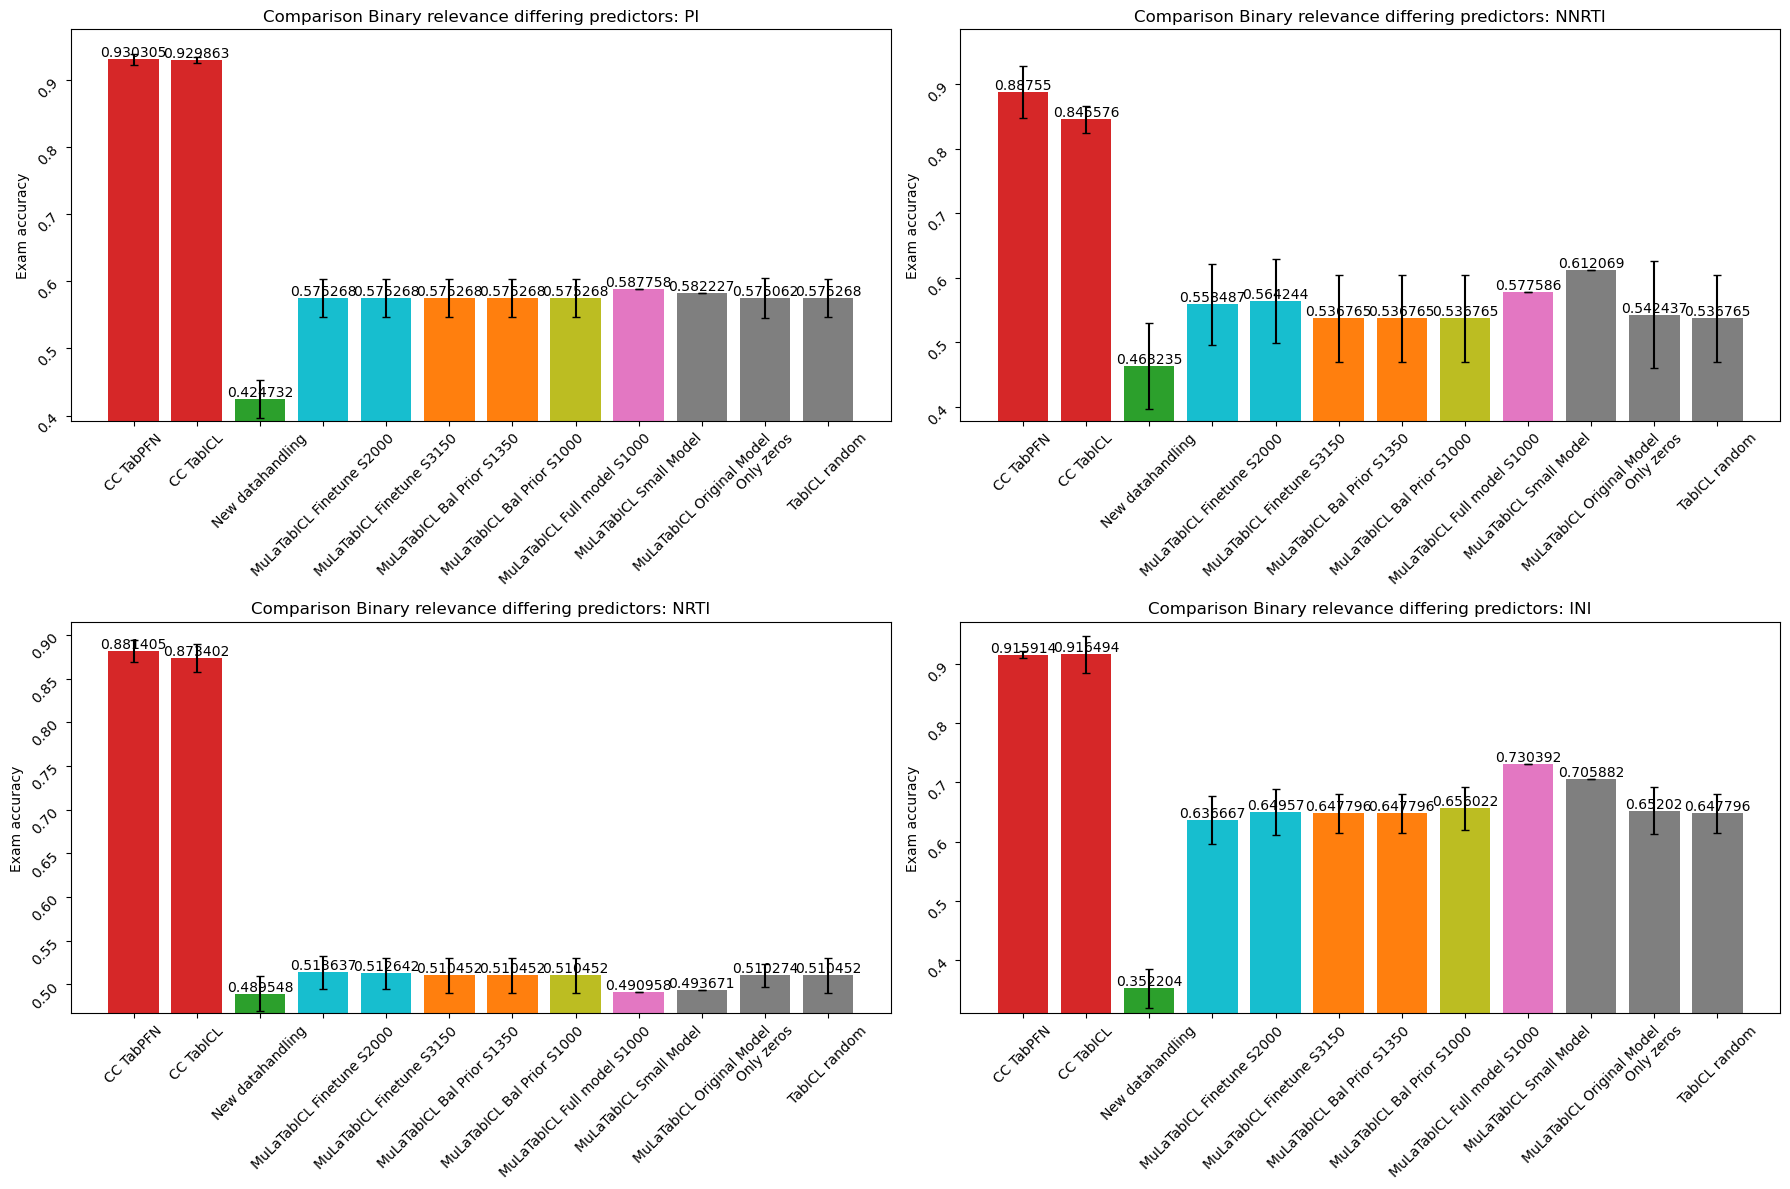

In [13]:
models_w_TabPFN = ["CC TabPFN", "CC TabICL", "New datahandling", "MuLaTabICL Finetune S2000", "MuLaTabICL Finetune S3150", "MuLaTabICL Bal Prior S1350", "MuLaTabICL Bal Prior S1000", "MuLaTabICL Full model S1000", "MuLaTabICL Small Model", "MuLaTabICL Original Model", "Only zeros", "TabICL random"]

color = ["tab:red"] * 2 + ["tab:green"] +  ["tab:cyan"] * 2 + ["tab:orange"] * 2 + ["tab:olive"] + ["tab:pink"] + ["tab:gray"] * 3

fig, axs = plt.subplots(2, 2, figsize=(18, 12))
#fig.tight_layout()

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):


    labels = models_w_TabPFN
    p = axs[i].bar(labels, df_sub_accs_groups_mean[drug], color=color)
    axs[i].errorbar(labels, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")


    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].tick_params(rotation=45)
    axs[i].set_ylabel('Exam accuracy')
    axs[i].set_ylim(max(0, (df_sub_accs_groups_mean[drug].min() - df_sub_accs_groups_std[drug].max()) * 0.995), min(1.0 + df_sub_accs_groups_std[drug].max(), (df_sub_accs_groups_mean[drug].max() + df_sub_accs_groups_std[drug].max())  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)

fig.tight_layout()
#plt.show()

#plt.savefig("../figures/All_benchmark_comparison_examAcc_wTabICL_wo_NaN.png")

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import prediction_handler as result_handler
import os
from sklearn.metrics import jaccard_score, roc_auc_score
import result_handler

#setting filepaths of the results

pi_results_filepath = "./prediction_results/PI_results/PI_"

nnrti_results_filepath = "./prediction_results/NNRTI_results/NNRTI_"

nrti_results_filepath = "./prediction_results/NRTI_results/NRTI_"

ini_results_filepath = "./prediction_results/INI_results/INI_"



#creating lists with filepaths for later visualisation
filepath_list = [pi_results_filepath, nnrti_results_filepath, nrti_results_filepath, ini_results_filepath]

modeltype = "MuLaTabICL_"

models = [
    "finetune_step-1250",
    "finetune_stage3_step-50",
    "bal_prior_step-1000",
    "finetune_step-2000",
    "bal_prior_step-1350",
    "finetune_step-3150",
    "full_model_step-1000",
    "abicl-classifier-v1.1-0506",
    "random_test/step-1"]

ending = "_5_fold_scene_dataset.csv"

thrshlds_internal = {"finetune_step-1250":  0.6860411,
"bal_prior_step-1000":  0.5292327,
"finetune_step-2000":  0.747135,
"bal_prior_step-1350":  0.504576,
"finetune_step-3150":  0.67952967,
"full_model_step-1000":  0.581367369,
"abicl-classifier-v1.1-0506":  0.709058,
"random_test/step-1":  np.nan,}

thrshlds_temp_sig = {"finetune_step-1250":  0.7540253,
"bal_prior_step-1000":  0.52958435,
"finetune_step-2000":  0.79760474,
"bal_prior_step-1350":  0.5100705,
"finetune_step-3150":  0.67292804,
"full_model_step-1000":  0.748620175,
"abicl-classifier-v1.1-0506":  0.7361159,
"random_test/step-1":  np.nan,}

thrshlds_temp_sig_new = {"finetune_step-1250":  0.6830695,
"finetune_stage3_step-50":  0.62230235,
"bal_prior_step-1000":  0.53245866,
"finetune_step-2000":  0.721869,
"bal_prior_step-1350":  0.5226037,
"finetune_step-3150":  0.82249993,
"full_model_step-1000":  0.73285752,
"abicl-classifier-v1.1-0506":  0.7113368,
"random_test/step-1":  np.nan,}



results = []


path="../prediction_results/scene.csv_results/scene.csv_"



roc_auc = []
prc_auc = []
old_acc = []



print("============" + path.split("/")[-1].strip("_") + "============")

for model in models:

    print(model)

    pred = pd.read_csv(path + modeltype + model + ending)
    pred_proba = pd.read_csv(path + modeltype + model + "_probabilities" + ending)

    true_labels = pred.filter(regex="True_*")
    pred_labels_old = pred.filter(regex="Pred_*")
    pred_proba = pred_proba.filter(regex="Pred_*")
    #print(max(pred_proba.max()), min(pred_proba.min()))

    true_label_arr = np.array(true_labels)
    pred_proba_arr = np.array(pred_proba)

    roc_auc.append(roc_auc_score(true_label_arr, pred_proba_arr))
    prc_auc.append(result_handler.prc_auc_score(true_label_arr, pred_proba_arr, multiclass="ovr"))

    old_acc.append(result_handler.exam_acc(pred_labels_old, true_labels))




model_results= {"ROC AUC":roc_auc,
                             "PRC AUC":prc_auc,
                             "Base Acc": old_acc,}

results.append(model_results)


============scene.csv============
finetune_step-1250
finetune_stage3_step-50
bal_prior_step-1000
finetune_step-2000
bal_prior_step-1350
finetune_step-3150
full_model_step-1000
abicl-classifier-v1.1-0506
random_test/step-1


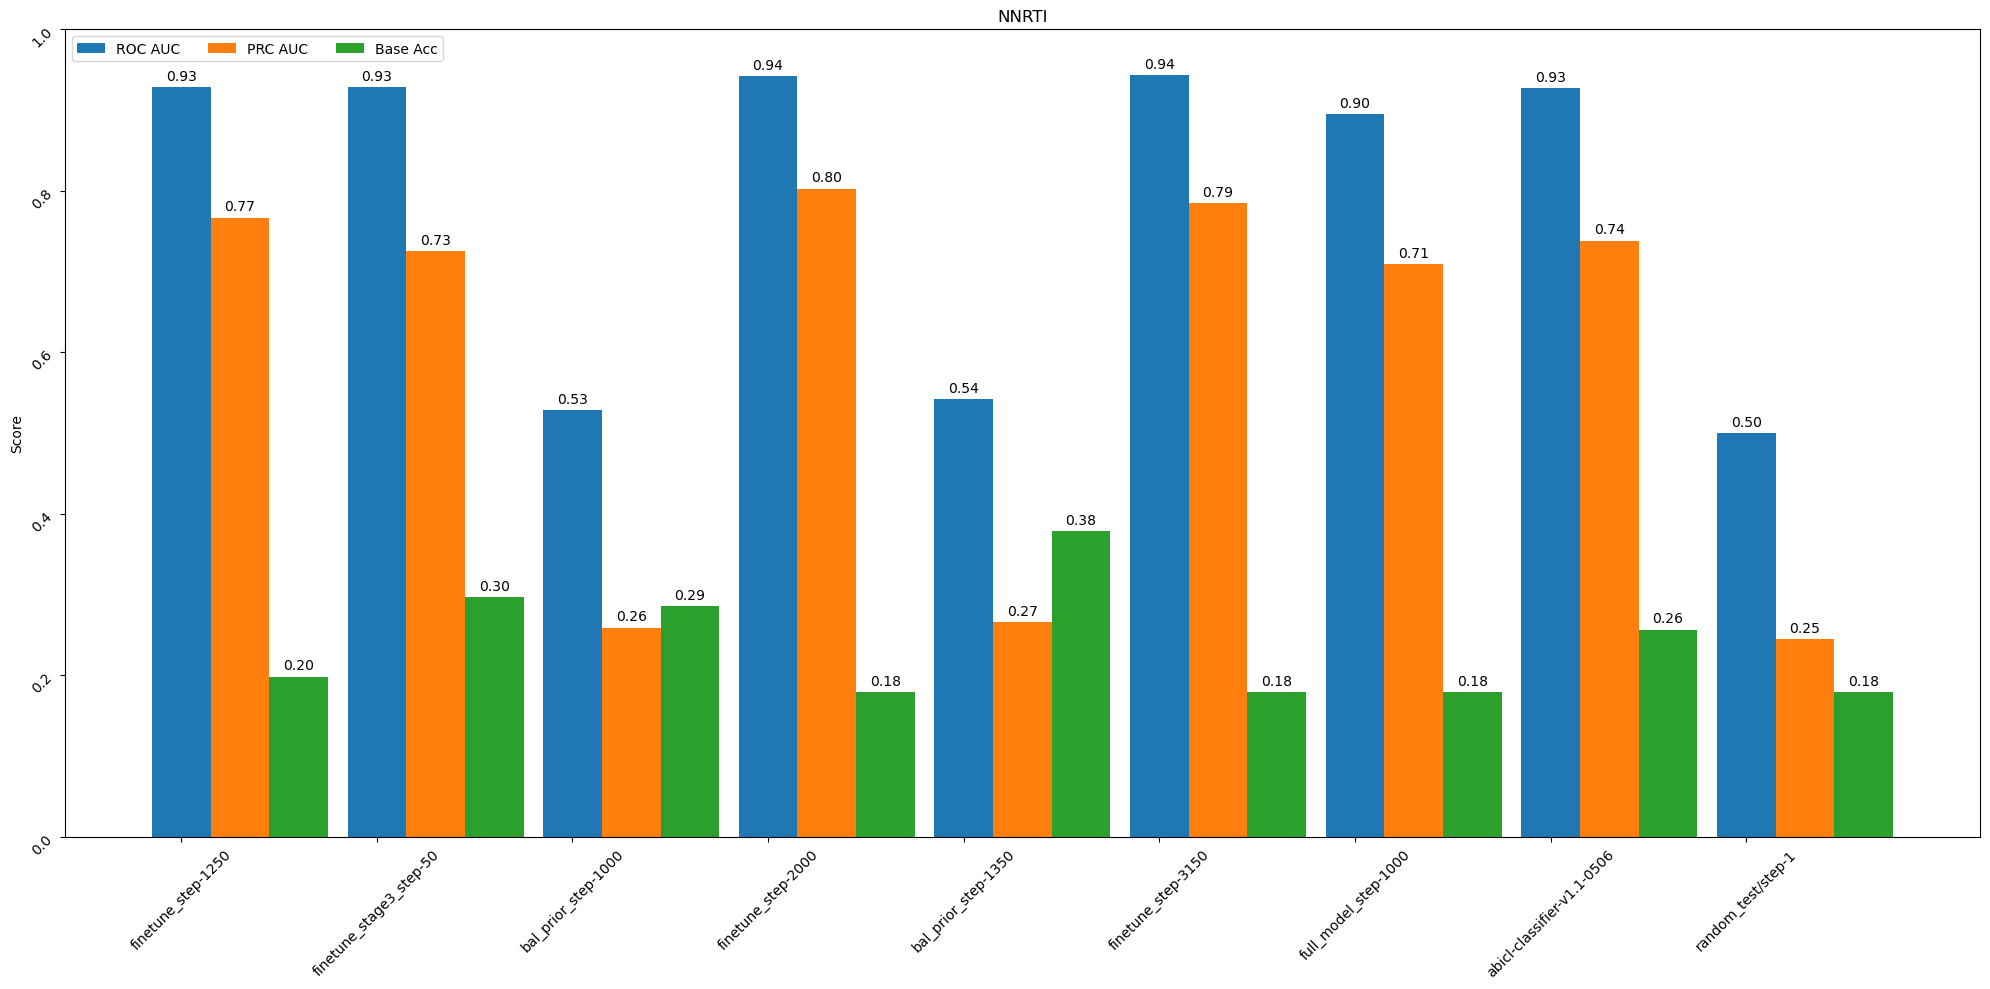

In [6]:

import numpy as np

x_ticks = models

x = np.arange(len(x_ticks))  # the label locations
width = 0.3  # the width of the bars

fig, axs = plt.subplots( figsize=(20, 10),layout='tight')


multiplier = 1.0

ax = axs

for attribute, measurement in results[0].items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, fmt='%.2f', padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_title(path.split("/")[-1].strip("_"))
ax.tick_params(rotation=45)
ax.set_xticks(x + width, x_ticks)
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 1)

plt.show()